In [2]:
import pandas as pd

df = pd.read_parquet(
    "../data/processed/crisisbench_train_processed.parquet"
)

In [3]:
df.shape

(109796, 10)

In [4]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gorbe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gorbe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [5]:
X = df["preprocessed_text"]
y = df["class_label"]

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 87836
Testing samples: 21960


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (87836, 20000)
Testing shape: (21960, 20000)


In [12]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [13]:
log_reg.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [14]:
y_pred = log_reg.predict(X_test_tfidf)

In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Baseline Accuracy:", accuracy)

Baseline Accuracy: 0.856511839708561


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    informative       0.87      0.89      0.88     13166
not_informative       0.83      0.81      0.82      8794

       accuracy                           0.86     21960
      macro avg       0.85      0.85      0.85     21960
   weighted avg       0.86      0.86      0.86     21960



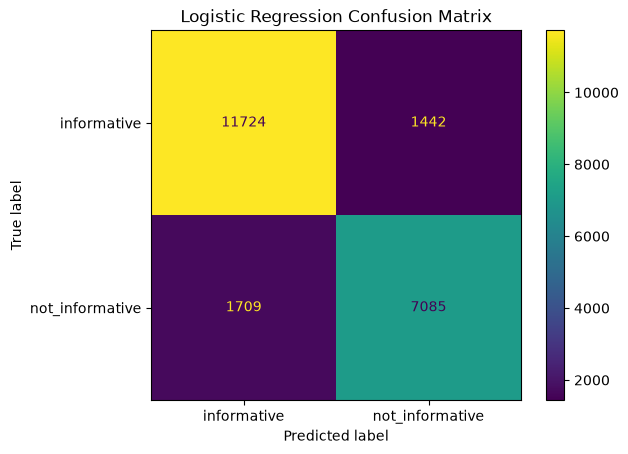

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [18]:
feature_names = tfidf.get_feature_names_out()
coefficients = log_reg.coef_[0]

top_positive = coefficients.argsort()[-20:][::-1]
top_negative = coefficients.argsort()[:20]

print("Top features for class 1:")
for i in top_positive:
    print(feature_names[i], coefficients[i])

print("\nTop features for class 0:")
for i in top_negative:
    print(feature_names[i], coefficients[i])

Top features for class 1:
mora 3.8568501588747366
patricia 3.745198805868556
song 3.3016752232139366
lol 2.886075175883722
rubyph 2.7961794923275534
jordan 2.73207316129285
nigga 2.6880931988504915
dance 2.6806312334160083
landoph 2.6481973738515645
fiji 2.5283410192448104
love 2.472712269017957
baltimore 2.4169451665110055
haha 2.3514481521335915
hurricane maria 2.2396285259266016
hair 2.1594044337467055
birthday 2.134912048887321
hurricane patricia 2.131705277382484
hahaha 2.073427446830563
smile 2.0452017968853515
excited 2.0279090923178003

Top features for class 0:
hurricane -12.110248249461774
flood -11.459749987714687
tornado -9.589964670170025
rt -8.628139477720396
yycflood -8.616794633479167
explosion -8.567737482841514
sandy -7.965897513892605
prayforboston -7.897941667693152
abflood -7.4231643315240055
earthquake -6.9389087021571285
mer -6.590775621710867
flooding -6.262713193583209
ebola -6.191469399360412
bombing -5.689707927433784
bostonmarathon -5.687309215101297
nswfire

In [19]:
print(log_reg.classes_)

['informative' 'not_informative']


In [20]:
df["class_label"].value_counts()

class_label
informative        65826
not_informative    43970
Name: count, dtype: int64

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=30
)

word_matrix = count_vectorizer.fit_transform(df["preprocessed_text"])

word_counts = word_matrix.sum(axis=0).A1

keywords = pd.DataFrame({
    "word": count_vectorizer.get_feature_names_out(),
    "frequency": word_counts
}).sort_values("frequency", ascending=False)

keywords

,word,frequency
21,rt,20966
12,hurricane,6828
4,earthquake,6459
20,people,5996
10,help,5928
6,flood,5849
17,nepal,5047
0,amp,4409
15,like,4109
16,need,3969


In [23]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [24]:
sample_text = df["text"].iloc[0]

doc = nlp(sample_text)

[(ent.text, ent.label_) for ent in doc.ents]

[('Haiti', 'GPE')]

In [25]:
spacy.explain("GPE")
spacy.explain("LOC")

'Non-GPE locations, mountain ranges, bodies of water'

In [26]:
crisis_words = r"\b(flood|earthquake|hurricane|tornado|explosion|typhoon)\b"

crisis_samples = df[
    df["clean_text"].str.contains(crisis_words, case=False, regex=True, na=False)
].sample(5, random_state=42)

C:\Users\gorbe\AppData\Local\Temp\ipykernel_69984\2902722920.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["clean_text"].str.contains(crisis_words, case=False, regex=True, na=False)


In [27]:
for text in crisis_samples["text"]:
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]

    print("TEXT:", text)
    print("ENTITIES:", entities)
    print("-" * 80)

TEXT: RT @dost_pagasa: At 06:00PM 4/DEC/2012, the eye of Typhoon #PabloPH was located @30km Southwest of Dumaguete City (9.2°N 123.0°E). http: ...
ENTITIES: [('06:00PM 4/DEC/2012', 'DATE'), ('Typhoon #', 'EVENT'), ('PabloPH', 'PERSON'), ('Dumaguete City', 'GPE'), ('9.2', 'CARDINAL')]
--------------------------------------------------------------------------------
TEXT: FTSE 100 expected lower as Hurricane Sandy - http://t.co/q1n1susp
ENTITIES: [('FTSE', 'ORG'), ('100', 'CARDINAL'), ('Hurricane Sandy - http://t.co/q1n1susp', 'FAC')]
--------------------------------------------------------------------------------
TEXT: https://t.co/Z4mxTO7fpp Indian Navy carries out relief operations in flood-hit Sri Lanka https://t.co/VUbcpnUwfq
ENTITIES: [('Indian Navy', 'ORG'), ('Sri Lanka', 'GPE')]
--------------------------------------------------------------------------------
TEXT: The Bangladeshi government announced Thursday it was sending medical teams to flood-hit areas to check the outbreak of

In [28]:
def extract_entities(text):
    doc = nlp(text)

    return [
        {
            "entity": ent.text,
            "label": ent.label_
        }
        for ent in doc.ents
    ]

In [29]:
sample = df["text"].iloc[0]

extract_entities(sample)

[{'entity': 'Haiti', 'label': 'GPE'}]

In [30]:
def extract_entity_types(text):
    doc = nlp(text)

    entities = {}

    for ent in doc.ents:
        entities.setdefault(ent.label_, []).append(ent.text)

    return entities

In [31]:
extract_entity_types(sample)

{'GPE': ['Haiti']}

In [33]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
word_freq = dict(
    zip(
        keywords["word"],
        keywords["frequency"]
    )
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate_from_frequencies(word_freq)

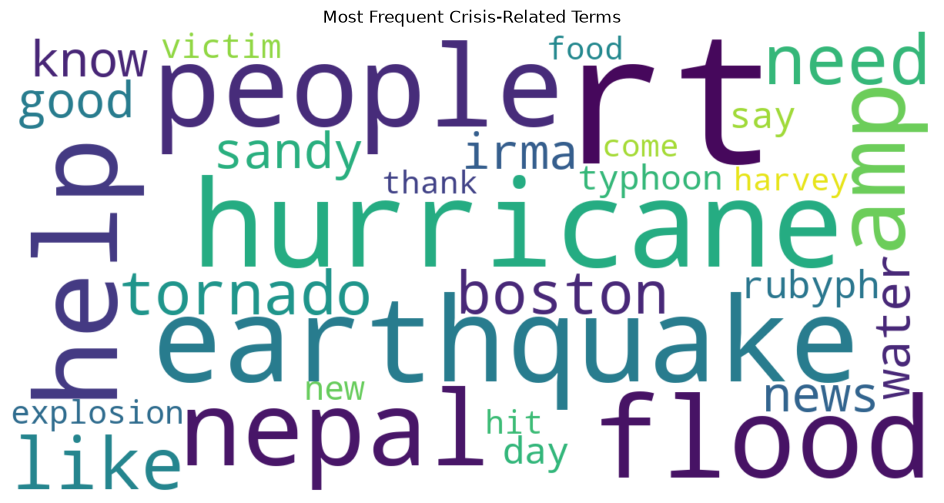

In [34]:
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Crisis-Related Terms")
plt.show()

In [35]:
from transformers import pipeline
sentiment_pipeline = pipeline(
    "sentiment-analysis"
)

c:\Users\gorbe\anaconda3\envs\social-media-analytics\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
c:\Users\gorbe\anaconda3\envs\social-media-analytics\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\gorbe\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by

In [36]:
sample = df["text"].iloc[0]

sentiment_pipeline(sample)

[{'label': 'NEGATIVE', 'score': 0.9991124272346497}]

In [37]:
sample_texts = df["text"].sample(10, random_state=42).tolist()

sentiment_results = sentiment_pipeline(
    sample_texts,
    truncation=True
)

for text, result in zip(sample_texts, sentiment_results):
    print("TEXT:", text)
    print("SENTIMENT:", result)
    print("-" * 80)

TEXT: Slowly moving 'Ruby' to bring torrential rains http://t.co/1JXuR4APuP #RubyPH
SENTIMENT: {'label': 'POSITIVE', 'score': 0.9680024981498718}
--------------------------------------------------------------------------------
TEXT: MT @dineshakula Med supplies required in Bir Hospital. Out of medical supplies http://t.co/4pPhg2aVhg #Kathmandu #NepalQuake #hmrd
SENTIMENT: {'label': 'NEGATIVE', 'score': 0.9966787099838257}
--------------------------------------------------------------------------------
TEXT: The Chinese Embassy in Manila express condolences to Typhoon Yolanda victims. |via Hua Zhang, embassy spokesman
SENTIMENT: {'label': 'POSITIVE', 'score': 0.9799394607543945}
--------------------------------------------------------------------------------
TEXT: Rwanda remembers genocide victims 20 years on - http://t.co/7ewhwgpybO
SENTIMENT: {'label': 'NEGATIVE', 'score': 0.9885667562484741}
--------------------------------------------------------------------------------
TEXT: FOX NE

In [4]:
import pandas as pd
import torch

print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [5]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

c:\Users\gorbe\anaconda3\envs\social-media-analytics\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\gorbe\anaconda3\envs\social-media-analytics\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\gorbe\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an admin

In [6]:
from datasets import Dataset

In [7]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["class_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
train_sample = pd.DataFrame({
    "text": X_train,
    "label": y_train
}).sample(
    30000,
    random_state=42
)

test_sample = pd.DataFrame({
    "text": X_test,
    "label": y_test
}).sample(
    5000,
    random_state=42
)

In [9]:
print("Train:", len(train_sample))
print("Test:", len(test_sample))

Train: 30000
Test: 5000


In [10]:
train_dataset = Dataset.from_pandas(
    train_sample[["text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_sample[["text", "label"]],
    preserve_index=False
)
train_dataset[0]

{'text': 'i am saying it as if i am not taken need this free just love spending time with my roost',
 'label': 'not_informative'}

In [11]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [12]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

Map: 100%|██████████| 5000/5000 [00:00<00:00, 11600.79 examples/s]


In [13]:
tokenized_train[0]

{'text': 'i am saying it as if i am not taken need this free just love spending time with my roost',
 'label': 'not_informative',
 'input_ids': [101,
  1045,
  2572,
  3038,
  2009,
  2004,
  2065,
  1045,
  2572,
  2025,
  2579,
  2342,
  2023,
  2489,
  2074,
  2293,
  5938,
  2051,
  2007,
  2026,
  20996,
  14122,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'token_type_ids': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,

In [14]:
label2id = {
    "informative": 0,
    "not_informative": 1
}

id2label = {
    0: "informative",
    1: "not_informative"
}

In [15]:
print(train_dataset.features)

{'text': Value('large_string'), 'label': Value('large_string')}


In [17]:
def convert_label(example):
    example["label"] = label2id[example["label"]]
    return example

train_dataset = train_dataset.map(convert_label)
test_dataset = test_dataset.map(convert_label)

Map: 100%|██████████| 5000/5000 [00:00<00:00, 40984.41 examples/s]


In [18]:
print(train_dataset[0]["label"])

1


In [20]:
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print("Using:", device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8332.12it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using: cuda


In [21]:
from transformers import TrainingArguments, Trainer
training_args = TrainingArguments(
    output_dir="../models/distilbert-crisisbench",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    fp16=True,
    logging_steps=100,
    report_to="none",
    load_best_model_at_end=True
)

In [22]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "macro_f1": f1,
        "precision": precision,
        "recall": recall
    }

In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

In [25]:
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])
print(tokenized_train.column_names)

['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [26]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

In [28]:
def convert_label(example):
    example["label"] = label2id[example["label"]]
    return example

tokenized_train = tokenized_train.map(convert_label)
tokenized_test = tokenized_test.map(convert_label)

Map: 100%|██████████| 5000/5000 [00:00<00:00, 26041.23 examples/s]


In [29]:
print(tokenized_train[0])

{'label': '1', 'input_ids': [101, 1045, 2572, 3038, 2009, 2004, 2065, 1045, 2572, 2025, 2579, 2342, 2023, 2489, 2074, 2293, 5938, 2051, 2007, 2026, 20996, 14122, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [34]:
def convert_label(example):
    example["label"] = int(example["label"])
    return example

tokenized_train = tokenized_train.map(convert_label)
tokenized_test = tokenized_test.map(convert_label)

Map: 100%|██████████| 5000/5000 [00:00<00:00, 24154.70 examples/s]


In [37]:
label2id = {
    "informative": 0,
    "not_informative": 1
}

train_sample["label"] = train_sample["label"].map(label2id)
test_sample["label"] = test_sample["label"].map(label2id)

In [38]:
print(train_sample["label"].value_counts())
print(test_sample["label"].value_counts())

label
0    17948
1    12052
Name: count, dtype: int64
label
0    3022
1    1978
Name: count, dtype: int64


In [39]:
train_dataset = Dataset.from_pandas(
    train_sample[["text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_sample[["text", "label"]],
    preserve_index=False
)

In [40]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

Map: 100%|██████████| 5000/5000 [00:00<00:00, 17605.70 examples/s]


In [41]:
tokenized_train = tokenized_train.remove_columns(["text", "token_type_ids"])
tokenized_test = tokenized_test.remove_columns(["text", "token_type_ids"])

In [44]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)
print(tokenized_train.column_names)
print(type(tokenized_train[0]["label"]))

['label', 'input_ids', 'attention_mask']
<class 'int'>


In [45]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,0.314045,0.325635,0.870400,0.862253,0.869926,0.856982
2,0.249653,0.389147,0.876200,0.869623,0.872638,0.867107


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.05it/s]


TrainOutput(global_step=7500, training_loss=0.32151936264038083, metrics={'train_runtime': 878.9411, 'train_samples_per_second': 68.264, 'train_steps_per_second': 8.533, 'total_flos': 1987010979840000.0, 'train_loss': 0.32151936264038083, 'epoch': 2.0})

In [46]:
eval_results = trainer.evaluate()

eval_results

print("Transformer Accuracy:", eval_results["eval_accuracy"])
print("Transformer Macro F1:", eval_results["eval_macro_f1"])

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Precision,Recall
0.249653,0.325635,2,0.870400,0.862253,0.869926,0.856982


Transformer Accuracy: 0.8704
Transformer Macro F1: 0.8622527692295134


In [47]:
predictions = trainer.predict(tokenized_test)

y_pred_transformer = predictions.predictions.argmax(axis=-1)
y_true_transformer = predictions.label_ids

In [48]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_transformer,
        y_pred_transformer,
        target_names=["informative", "not_informative"]
    )
)

                 precision    recall  f1-score   support

    informative       0.87      0.92      0.90      3022
not_informative       0.87      0.79      0.83      1978

       accuracy                           0.87      5000
      macro avg       0.87      0.86      0.86      5000
   weighted avg       0.87      0.87      0.87      5000



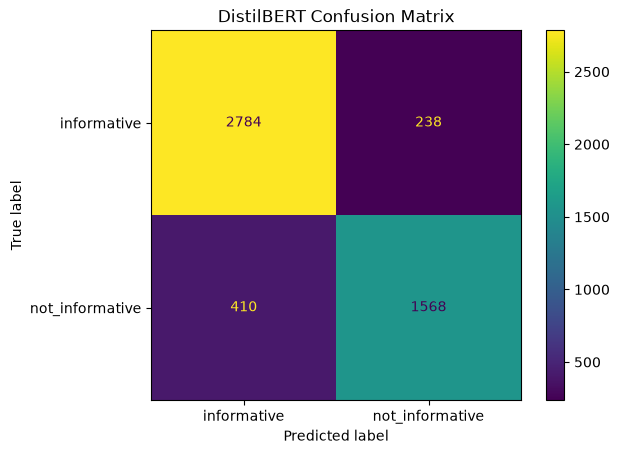

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_transformer = confusion_matrix(
    y_true_transformer,
    y_pred_transformer
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_transformer,
    display_labels=["informative", "not_informative"]
)

disp.plot()
plt.title("DistilBERT Confusion Matrix")
plt.show()

In [50]:
model_save_path = "../models/distilbert-crisisbench"

trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.63it/s]


('../models/distilbert-crisisbench\\tokenizer_config.json',
 '../models/distilbert-crisisbench\\tokenizer.json')

In [51]:
import os

print(os.path.exists(model_save_path))

True


In [52]:
import torch

sample_posts = test_sample["text"].sample(5, random_state=42).tolist()

for text in sample_posts:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)
    predicted_class = probabilities.argmax().item()
    confidence = probabilities[0, predicted_class].item()

    print("TEXT:", text)
    print("PREDICTION:", id2label[predicted_class])
    print("CONFIDENCE:", round(confidence, 4))
    print("-" * 100)

TEXT: if my child is sick, where should i take him/her?
PREDICTION: informative
CONFIDENCE: 0.6202
----------------------------------------------------------------------------------------------------
TEXT: can i just say 1 thing?
PREDICTION: not_informative
CONFIDENCE: 0.9919
----------------------------------------------------------------------------------------------------
TEXT: the country's macroeconomic and fiscal stability has contributed to steady improvement in several economic and social indicators.
PREDICTION: not_informative
CONFIDENCE: 0.8519
----------------------------------------------------------------------------------------------------
TEXT: yep! and the horrible wind!!! so scary!!!
PREDICTION: not_informative
CONFIDENCE: 0.9578
----------------------------------------------------------------------------------------------------
TEXT: furthermore, poor grazing conditions are threatening livestock in the country and a considerable number of large and small stock have al

In [53]:
import json

nlp_results = {
    "tfidf_logistic_regression": {
        "accuracy": 0.856,
        "macro_f1": 0.8500
    },
    "distilbert": {
        "accuracy": 0.8704,
        "macro_f1": 0.8622,
        "informative_f1": 0.90,
        "not_informative_f1": 0.83
    }
}

with open("../models/nlp_results.json", "w") as f:
    json.dump(nlp_results, f, indent=4)

In [54]:
import os

print(os.path.exists("../models/nlp_results.json"))

True


In [55]:
def predict_post(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)

    predicted_class = probabilities.argmax().item()
    confidence = probabilities[0, predicted_class].item()

    return {
        "prediction": id2label[predicted_class],
        "confidence": round(confidence, 4)
    }

In [58]:

predict_post(
    "Had a great day with my friends today!"
)

{'prediction': 'not_informative', 'confidence': 0.9882}

In [64]:
def analyze_post(text):
    prediction = predict_post(text)
    entities = extract_entity_types(text)

    return {
        "prediction": prediction["prediction"],
        "confidence": prediction["confidence"],
        "entities": entities
    }

In [67]:
analyze_post(
    "A major earthquake has hit Kathmandu, Nepal. Rescue teams are helping people."
)

{'prediction': 'informative',
 'confidence': 0.9774,
 'entities': {'GPE': ['Kathmandu', 'Nepal']}}

In [63]:
def extract_entity_types(text):
    doc = nlp(text)

    entities = {}

    for ent in doc.ents:
        entities.setdefault(ent.label_, []).append(ent.text)

    return entities

In [66]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [68]:
result = analyze_post(
    "A major earthquake has struck Kathmandu, Nepal. Rescue teams are helping injured people and urgently need medical supplies."
)

result

{'prediction': 'informative',
 'confidence': 0.9847,
 'entities': {'GPE': ['Kathmandu', 'Nepal']}}

In [69]:
print("Prediction:", result["prediction"])
print("Confidence:", result["confidence"])
print("Entities:", result["entities"])

Prediction: informative
Confidence: 0.9847
Entities: {'GPE': ['Kathmandu', 'Nepal']}


In [70]:
trainer.save_model("../models/distilbert-crisisbench")
tokenizer.save_pretrained("../models/distilbert-crisisbench")


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.20it/s]


('../models/distilbert-crisisbench\\tokenizer_config.json',
 '../models/distilbert-crisisbench\\tokenizer.json')